<a href="https://colab.research.google.com/github/dora-kds/python-for-data-science/blob/master/python_practice_10_2025_my.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Оцінювання наявності даної роботи буде враховувати як наявність самих візуалізацій (вони можуть незначно відрізнятися від прикладів, але повинні змістовно відображати суть задачі) та опис отриманих вами результатів. При наявності ЛИШЕ візуалізацій без роз'яснень, завдання не буде зараховане за наявне.

Під час виконання вам дозволено користуватися будь-якими зручними для вас Python бібліотеками для візуалізації.

# I. Receiving Data.

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

1. (2б) Для виконання цієї лабораторної роботи Вам необхідно скористатися вибіркою titanic ([train.csv](https://www.kaggle.com/c/titanic/data?select=train.csv)). Зчитайте його та збережіть його у змінну, щоб у подальшому її використати для візуалізацій. Виведіть інформацію про кожну колонку, її індекс, тип та кількість непропущених значень та перші кілька рядків датафрейму.


In [11]:
df = pd.read_csv('train.csv')
df.info()
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# IІ. Data Visualization.

2. (10б) Створіть pie chart, який би показував співвідношення виживших до загиблих.

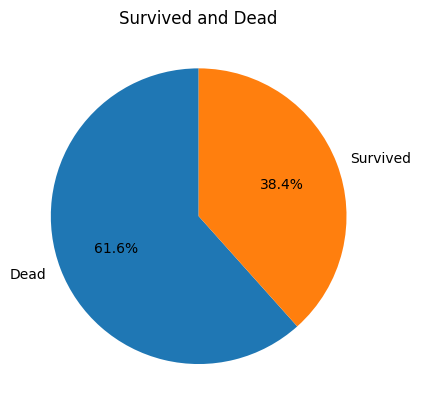

In [12]:
survived = df['Survived'].value_counts()
labels = ['Dead', 'Survived']
plt.figure()
plt.pie(survived, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title('Survived and Dead')
plt.show()

Більша частина пасажирів не вижила (61%). Катастрофа мала великий рівень смертності.

3. (20б) Створіть bar chart, який би показував співвідношення загиблих до виживших для кожної статі. Для groupby використовуйте атрибут as_index=False.


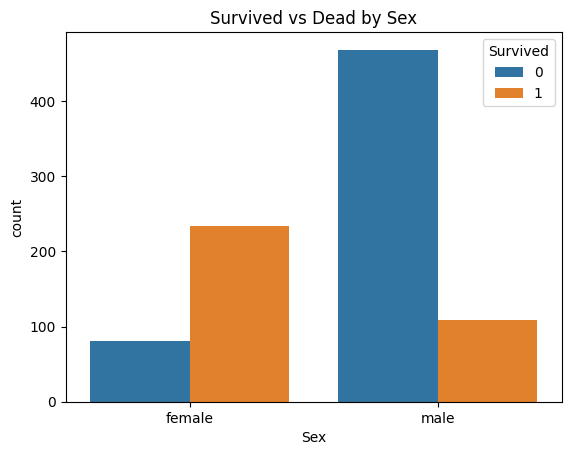

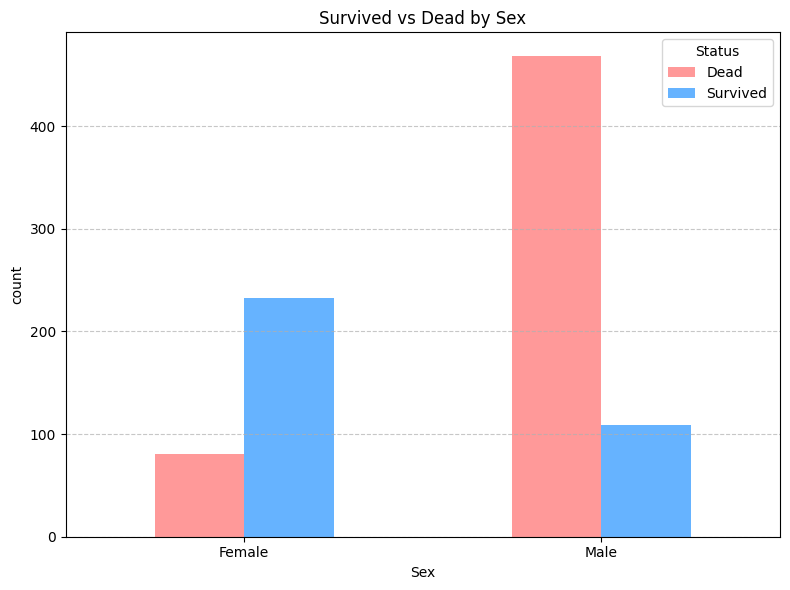

In [13]:
survival_by_gender = (
    df.groupby(['Sex', 'Survived'])
      .size()
      .unstack(fill_value=0)
)
survival_by_gender.columns = ['Dead', 'Survived']
survival_by_gender.index = ['Female', 'Male']

survival_by_gender.plot(
    kind='bar',
    figsize=(8, 6),
    color=['#ff9999', '#66b3ff']
)

plt.title('Survived vs Dead by Sex')
plt.xlabel('Sex')
plt.ylabel('count')
plt.xticks(rotation=0)
plt.legend(title='Status')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

З діаграми видно, чоловіки становлять більшість як загалом, так і серед загиблих. У жінок ситуація зворотня - більшість з них вижило. Це означає, що стать була суттєвим фактором у шансах на виживання під час катастрофи.

4. (20б) Відобразіть кількість пропущених значень в датасеті по кожній із змінних.

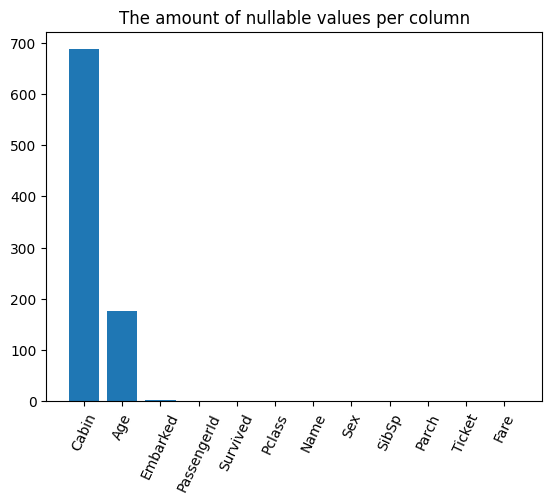

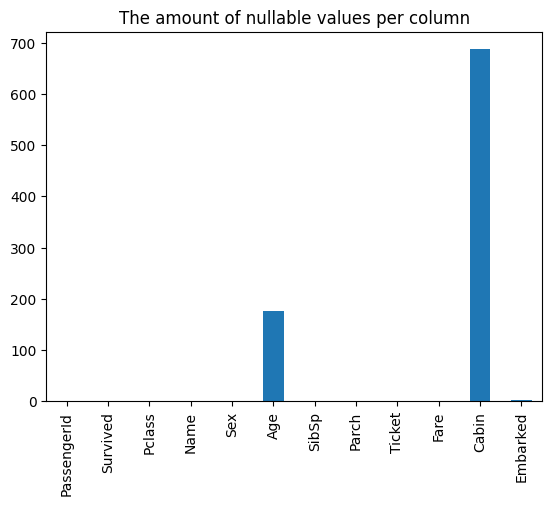

In [14]:
df.isnull().sum().plot(kind='bar')
plt.title('The amount of nullable values per column')

plt.show()

У результаті видно, що пропущені значення лише в двух колонках Age та Cabin, інші колонки коректно заповнені. на це важливо зважати при подальшому аналізі даних.

5. (10б) Побудуйте наступний графік, дайте йому назву та опишіть, що власне на них відображається.

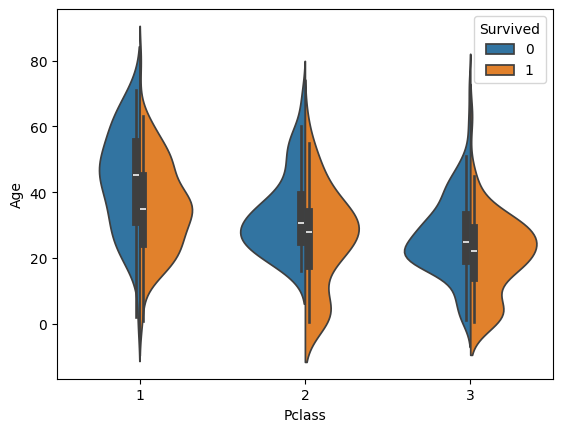

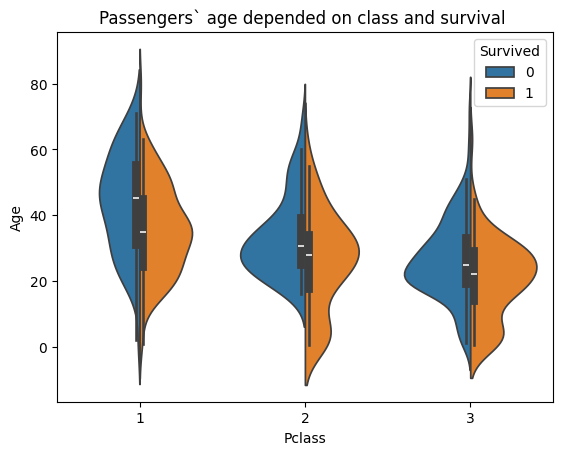

In [15]:
plt.figure()
sns.violinplot(data=df, x='Pclass', y='Age', hue='Survived', split='True')

plt.title('Passengers` age depended on class and survival ')
plt.show()

Дві осі графіка відповідають за вік пасажира та клас каюти. На графіку видно, що більша частка дорослих людей у 1 і 2 класах, молоді більше у - 3. Також, кількість загиблих значно вища у третьому класі. Загальний висновок: пасажири першого класумали кращі шанси вижити ніж інші.

6. (13б) Побудуйте графік розподілу частот по віку пасажирів.


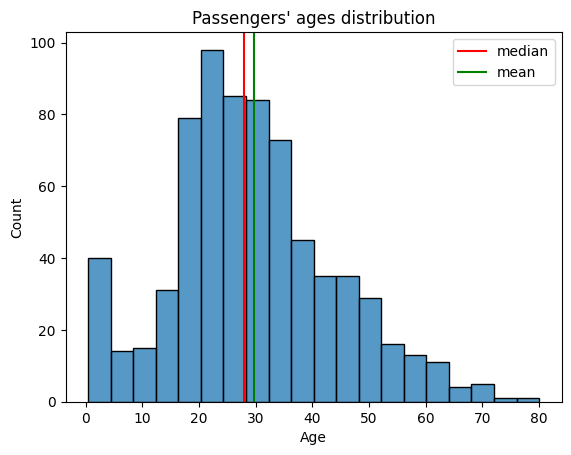

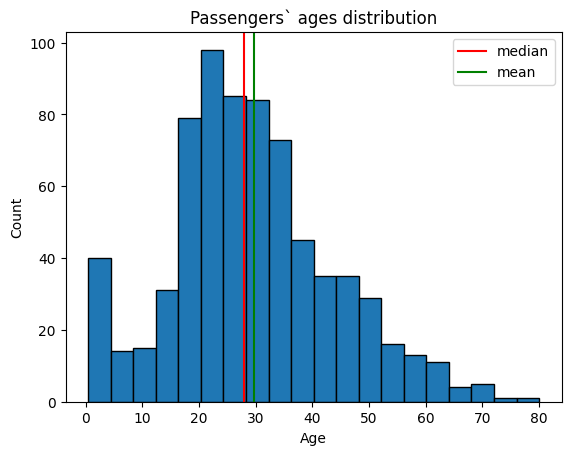

In [16]:
age = df['Age'].dropna()

mean_age = age.mean()
median_age = age.median()

plt.figure()
plt.hist(age, bins=20, edgecolor='black')
plt.axvline(median_age, label='median',color='red')
plt.axvline(mean_age, label='mean', color='green')

plt.title('Passengers` ages distribution')
plt.xlabel('Age')
plt.ylabel('Count')

plt.legend()

plt.show()

З графіка видно, що більшість пасажирів віком від 20 до 35. счереднє число більше за медіану, значить є досить велика кількість пасадирів 40+ (що ми і бачимо з графіку), також можн авідмітити велику кількість немовлят.

7. (25б) Поставте бізнес-питання до даних. Дайте на нього відповідь за допомогою візуалізацій. Прокоментуйте отриману відповідь.

наскільки соціальний статус людини (клас квитка) впливає на її шанси вижити?

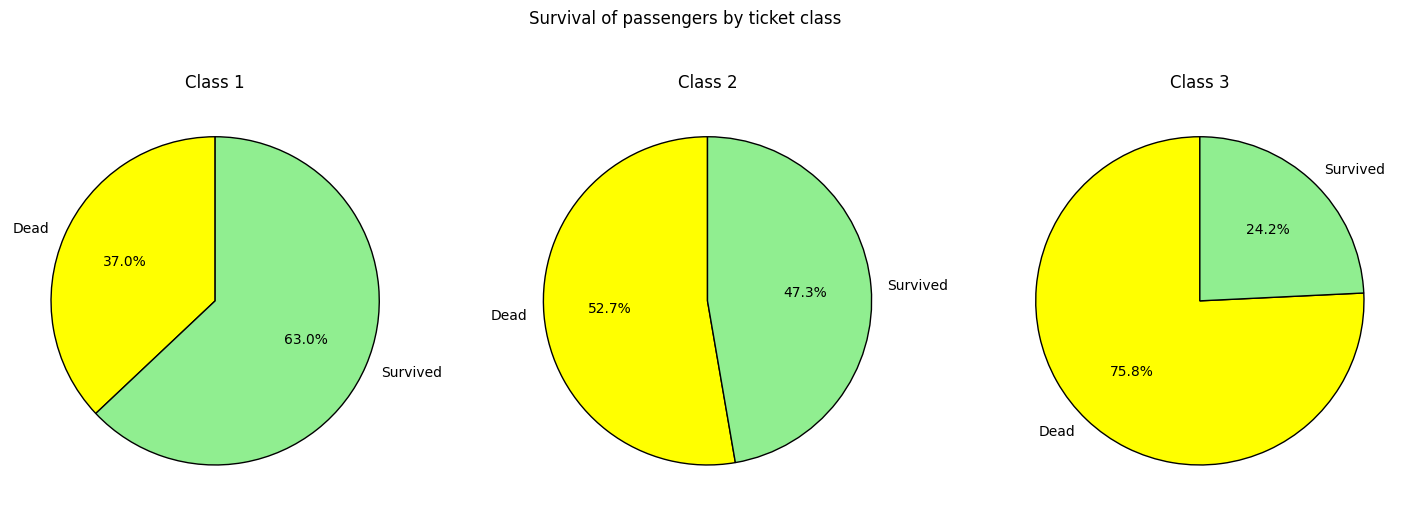

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18,6))

colors = ['yellow', 'lightgreen']

for i, pclass in enumerate([1, 2, 3]):
    passengers = df[df['Pclass']==pclass]
    counts = passengers['Survived'].value_counts().sort_index()
    counts = counts.reindex([0,1], fill_value=0)

    axes[i].pie(
        counts,
        labels=['Dead', 'Survived'],
        autopct='%1.1f%%',
        startangle=90,
        colors=colors,
        wedgeprops={'edgecolor': 'black'}
    )
    axes[i].set_title(f'Class {pclass}')

plt.suptitle('Survival of passengers by ticket class')
plt.show()

і тут можна легко побачити, як клас квитку впливає на шанс виживання(вище статус = більший шанс): від першого до третього - 67%, 47.3%, 24.2% відповідно.

# Вітаю! Ви велика(ий) молодець, що впоралась(вся). Похваліть себе та побалуйте чимось приємним. Я Вами пишаюся.

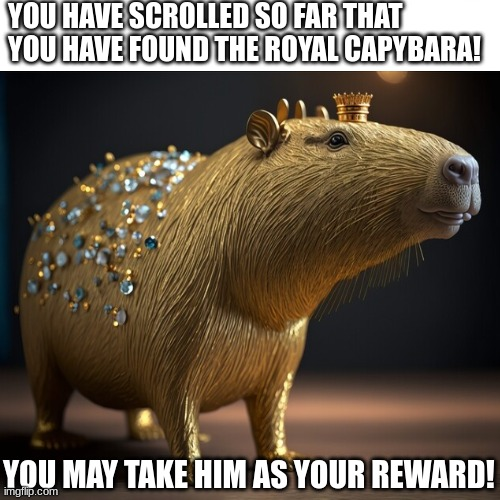